# TP1 — Data Preparation & Random Forest (Breast Cancer with Noise)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/DFGSM2-IA-S2/blob/main/session2/tp1_correction.ipynb)

## Objective

In session 1, we worked with a **clean dataset**. Real-world medical data is rarely clean — it contains **missing values**, **outliers**, and **categorical variables** that need preprocessing.

In this TP, we will:
1. Work with a **noised version** of the Breast Cancer dataset (missing values, outliers, categorical features)
2. Learn the full **data preparation pipeline**: imputation → outlier handling → encoding → scaling
3. Train a **Random Forest** classifier and compare it with logistic regression

### Methodology Recap (from Session 1)

The pipeline remains: **Explore → Visualize → Prepare → Train → Evaluate → Cross-validate**. This session focuses on the **Prepare** step, which we skipped in session 1 because the data was already clean.

> **Link to Session 1:** We reuse the same dataset and evaluation methodology. The new concepts are data preparation and a new model (Random Forest).

---
## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)

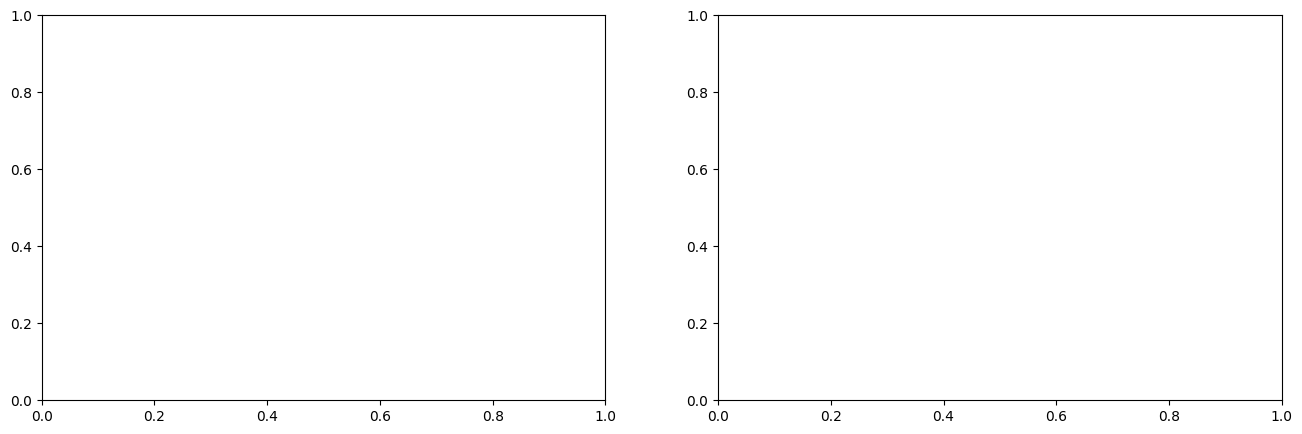

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

---
## 2. Load & Discover the Data

In session 1, the Breast Cancer Wisconsin dataset was **perfectly clean** — no missing values, no outliers, all numeric features. That's rare in real life!

This time, you receive a version of the same dataset that is closer to **real clinical data**:
- Some values are **missing** (equipment errors, incomplete patient records)
- Some measurements contain **outliers** (data entry mistakes, extreme cases)
- New **categorical columns** have been added (patient demographics)

Your first job as a data scientist: **discover and understand these issues** before any modeling.

### Exercise 1.1 — Load the dataset

Load the breast cancer dataset from the CSV file and display its shape, first rows, and target distribution.

**Why:** Always start by looking at your data. Unlike session 1 where the data was clean and ready to use, real datasets need inspection.

*Hint:* `pd.read_csv('breast_cancer_noisy.csv')`, `df.head()`, `df.shape`

In [38]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/racousin/DFGSM2-IA-S2/refs/heads/main/session2/breast_cancer_noisy.csv')

# Target info (same as session 1: 0=malignant, 1=benign)
target_names = np.array(['malignant', 'benign'])

# Identify column types
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('target').tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Shape: {df.shape}")
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {categorical_cols}")
df.head()

Shape: (569, 34)
Numeric features: 30
Categorical features: ['age_group', 'menopause_status', 'tumor_location']


/var/folders/n1/bdjyqqwn5t5cglz8mdg_13900000gn/T/ipykernel_2314/448331386.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,age_group,menopause_status,tumor_location
0,17.990000,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,0.1622,0.6656,0.7119,0.2654,0.4601,NaN,0,middle,pre,upper_inner
1,20.570000,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,0.1238,0.1866,0.2416,0.1860,NaN,0.08902,0,old,post,upper_inner
2,19.690000,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,old,post,central
3,87.142752,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,NaN,0.09744,...,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,middle,pre,upper_outer
4,20.290000,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,NaN,0.05883,...,0.1374,NaN,0.4000,0.1625,0.2364,0.07678,0,young,pre,lower_outer


In [39]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target', 'age_group', 'menopause_status', 'tumor_location'],
      dtype='str')

In [40]:
df.isnull()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,age_group,menopause_status,tumor_location
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
566,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
df["mean texture"].isnull().sum()

np.int64(33)

### Exercise 1.2 — Inspect data quality

Use `.info()` to see data types and missing values, and `.describe()` to check value ranges.

**Why:** Identify the three types of problems: missing values (NaN), outliers (extreme values), and categorical features (non-numeric).

*Hint:* `df.info()`, `df.describe()`

**Question:** How many missing values are there? Which features have suspicious values? Which columns are categorical?

In [42]:
print("=== Data Info ===")
df.info()

print("\n=== Summary Statistics ===")
df.describe()

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              543 non-null    float64
 1   mean texture             536 non-null    float64
 2   mean perimeter           542 non-null    float64
 3   mean area                544 non-null    float64
 4   mean smoothness          545 non-null    float64
 5   mean compactness         541 non-null    float64
 6   mean concavity           533 non-null    float64
 7   mean concave points      530 non-null    float64
 8   mean symmetry            542 non-null    float64
 9   mean fractal dimension   544 non-null    float64
 10  radius error             546 non-null    float64
 11  texture error            527 non-null    float64
 12  perimeter error          544 non-null    float64
 13  area error               534 non-null    float64
 14  smoothness error   

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,543.000000,536.000000,542.000000,544.000000,545.000000,541.000000,533.000000,530.000000,542.000000,544.000000,...,547.000000,538.000000,547.000000,545.000000,542.000000,548.000000,546.000000,536.000000,534.000000,569.000000
mean,16.475067,19.240784,91.828672,717.533486,0.096213,0.104319,0.090298,0.049291,0.180937,0.062779,...,25.562029,107.193234,872.234369,0.132556,0.254076,0.274202,0.115195,0.290810,0.084082,0.627417
std,15.268090,4.251682,24.562463,590.504934,0.014050,0.053341,0.080744,0.038850,0.026819,0.007058,...,6.088038,33.291238,558.893474,0.022867,0.157070,0.209434,0.066060,0.062362,0.018105,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.116700,0.049960,...,12.020000,50.410000,185.200000,0.081250,0.027290,0.000000,0.000000,0.156600,0.055040,0.000000
25%,11.755000,16.170000,74.690000,426.525000,0.085970,0.063760,0.029950,0.020362,0.161900,0.057697,...,20.970000,84.430000,515.550000,0.116600,0.147725,0.115925,0.064943,0.250475,0.071857,0.000000
50%,13.500000,18.785000,85.935000,561.700000,0.095660,0.092280,0.061950,0.033950,0.178950,0.061515,...,25.400000,97.745000,684.500000,0.131400,0.213000,0.229800,0.100550,0.282800,0.080075,1.000000
75%,16.255000,21.735000,104.025000,816.275000,0.105100,0.130500,0.132400,0.074632,0.195400,0.066090,...,29.420000,125.325000,1047.000000,0.146300,0.334150,0.385500,0.162500,0.318850,0.092075,1.000000
max,176.072082,39.280000,188.500000,7399.774357,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


**Answer:** There are approximately 850 missing values spread across numeric features (~5% of cells). `mean radius` and `mean area` have outliers visible from their max values (much higher than expected). `age_group`, `menopause_status`, and `tumor_location` are categorical (object type).

---
## 3. Visualize Data Issues

Before fixing problems, we need to **see** them. Visualization makes data issues obvious.

### Exercise 2.1 — Missing values heatmap

Visualize where missing values are located in the dataset.

**Why:** See the pattern of missing data — is it random or concentrated in certain features?

*Hint:* `sns.heatmap(df[numeric_cols].isnull(), cbar=True, yticklabels=False)` or `df[numeric_cols].isnull().sum().plot(kind='bar')`

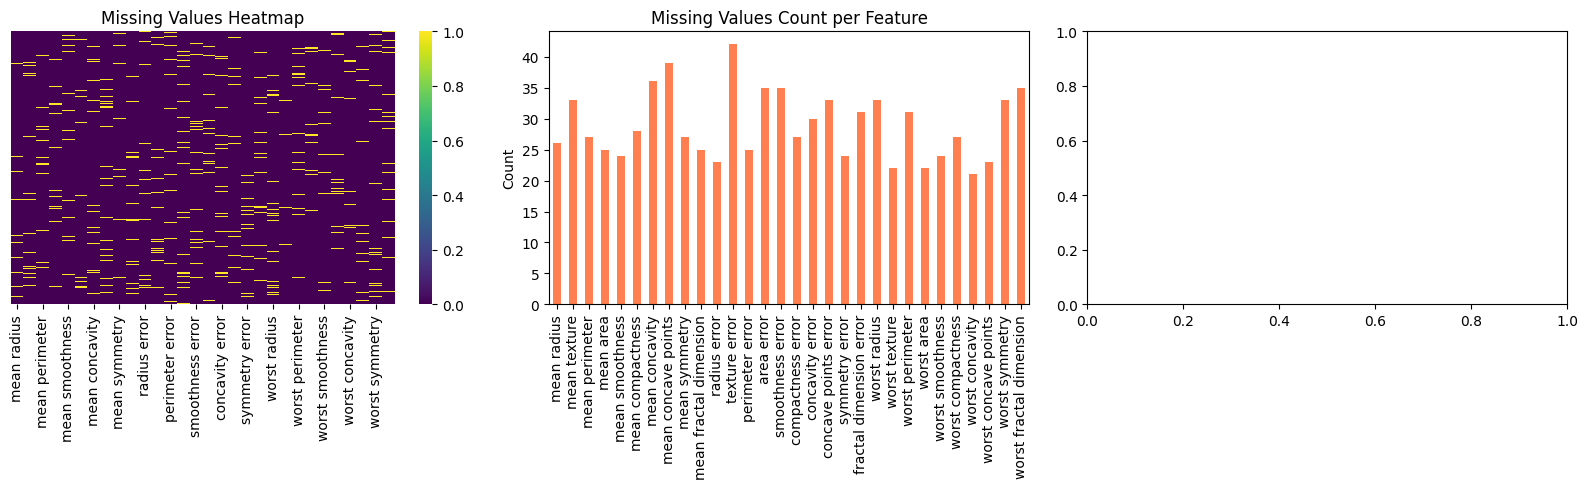

Total missing values: 866


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Heatmap of missing values
sns.heatmap(df[numeric_cols].isnull(), cbar=True, yticklabels=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Missing Values Heatmap')
axes[0].tick_params(axis='x', rotation=90)

# Bar plot of missing values per feature
df[numeric_cols].isnull().sum().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Missing Values Count per Feature')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Total missing values: {df[numeric_cols].isnull().sum().sum()}")

### Exercise 2.2 — Boxplots to detect outliers

Create boxplots for `mean radius` and `mean area` to visualize outliers.

**Why:** Boxplots show the median, quartiles, and **outliers** (points beyond 1.5× IQR). Extreme outliers will be clearly visible.

*Hint:* `fig, axes = plt.subplots(1, 2, figsize=(12, 5))`, `sns.boxplot(y=df['mean radius'], ax=axes[0])`

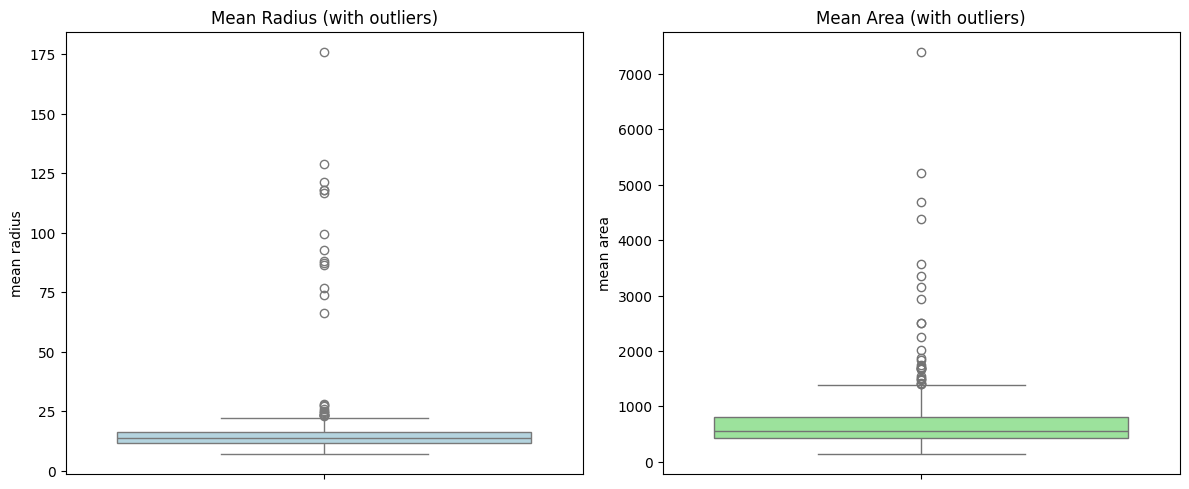

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['mean radius'], ax=axes[0], color='lightblue')
axes[0].set_title('Mean Radius (with outliers)')

sns.boxplot(y=df['mean area'], ax=axes[1], color='lightgreen')
axes[1].set_title('Mean Area (with outliers)')

plt.tight_layout()
plt.show()

### Exercise 2.3 — Categorical distributions

Plot bar charts for the categorical columns (`age_group`, `menopause_status`, `tumor_location`).

**Why:** Understand the distribution of categorical features and check if any category is very rare.

*Hint:* `df['age_group'].value_counts().plot(kind='bar')`

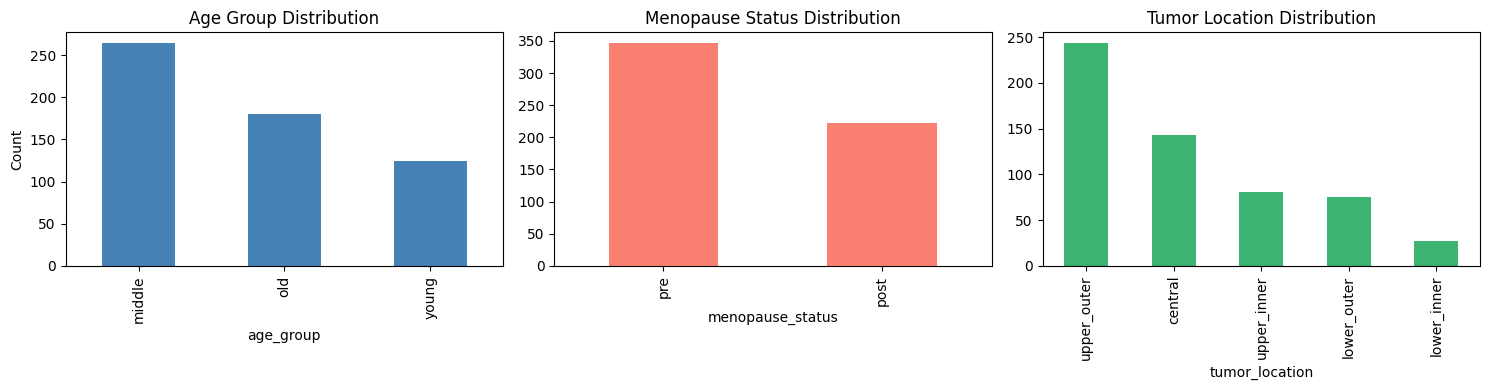

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['age_group'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Age Group Distribution')
axes[0].set_ylabel('Count')

df['menopause_status'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Menopause Status Distribution')

df['tumor_location'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Tumor Location Distribution')

plt.tight_layout()
plt.show()

---
## 4. Handle Missing Values

Missing values (NaN) must be handled before training — most ML models cannot work with NaN.

### Common strategies:
| Strategy | When to use |
|----------|------------|
| **Drop rows** | Very few missing values, large dataset |
| **Mean/Median imputation** | Numeric features, random missingness |
| **Most frequent imputation** | Categorical features |
| **Model-based imputation** | Complex patterns (advanced) |

We'll use `SimpleImputer` from sklearn:
- **Median** for numeric features (robust to outliers)
- **Most frequent** for categorical features

### Exercise 3.1 — Check missing values

Count missing values per column. How many total NaN values are there?

*Hint:* `df.isnull().sum()`, `df.isnull().sum().sum()`

In [46]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
mean radius                26
mean texture               33
mean perimeter             27
mean area                  25
mean smoothness            24
mean compactness           28
mean concavity             36
mean concave points        39
mean symmetry              27
mean fractal dimension     25
radius error               23
texture error              42
perimeter error            25
area error                 35
smoothness error           35
compactness error          27
concavity error            30
concave points error       33
symmetry error             24
fractal dimension error    31
worst radius               33
worst texture              22
worst perimeter            31
worst area                 22
worst smoothness           24
worst compactness          27
worst concavity            21
worst concave points       23
worst symmetry             33
worst fractal dimension    35
target                      0
age_group                   0
menopause_sta

### Exercise 3.2 — Impute missing values

Use `SimpleImputer` with `strategy='median'` for numeric features and `strategy='most_frequent'` for categorical features.

**Why:** Median is more robust than mean when outliers are present (which is our case!).

*Hint:*
```python
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
```

Verify with `df.isnull().sum().sum()` — should be 0.

In [47]:
# Impute numeric features with median
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Impute categorical features with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print(f"Total missing values after imputation: {df.isnull().sum().sum()}")

Total missing values after imputation: 0


---
## 5. Handle Outliers

Outliers are extreme values that can distort model training. We'll use the **IQR method** to detect and clip them.

### IQR Method
- **IQR** = Q3 − Q1 (interquartile range)
- **Lower bound** = Q1 − 1.5 × IQR
- **Upper bound** = Q3 + 1.5 × IQR
- Values outside these bounds are **clipped** (set to the bound value)

**Why clipping instead of removing?** In medical data, we don't want to lose samples — every patient matters. Clipping preserves the sample while reducing the outlier's influence.

### Exercise 4.1 — Detect and clip outliers

For each numeric feature, clip values outside the IQR bounds. Show before/after statistics for `mean radius`.

*Hint:*
```python
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
```

In [48]:
# Show before stats
print("Before clipping:")
print(f"  mean radius - min: {df['mean radius'].min():.2f}, max: {df['mean radius'].max():.2f}")
print(f"  mean area   - min: {df['mean area'].min():.2f}, max: {df['mean area'].max():.2f}")

# Clip outliers using IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("\nAfter clipping:")
print(f"  mean radius - min: {df['mean radius'].min():.2f}, max: {df['mean radius'].max():.2f}")
print(f"  mean area   - min: {df['mean area'].min():.2f}, max: {df['mean area'].max():.2f}")

Before clipping:
  mean radius - min: 6.98, max: 176.07
  mean area   - min: 143.50, max: 7399.77

After clipping:
  mean radius - min: 6.98, max: 22.55
  mean area   - min: 143.50, max: 1359.90


### Exercise 4.2 — Visualize before/after outlier handling

Create boxplots of `mean radius` and `mean area` after clipping. Compare with exercise 2.2.

**Why:** Verify that outliers have been effectively handled.

*Hint:* Same boxplot code as exercise 2.2.

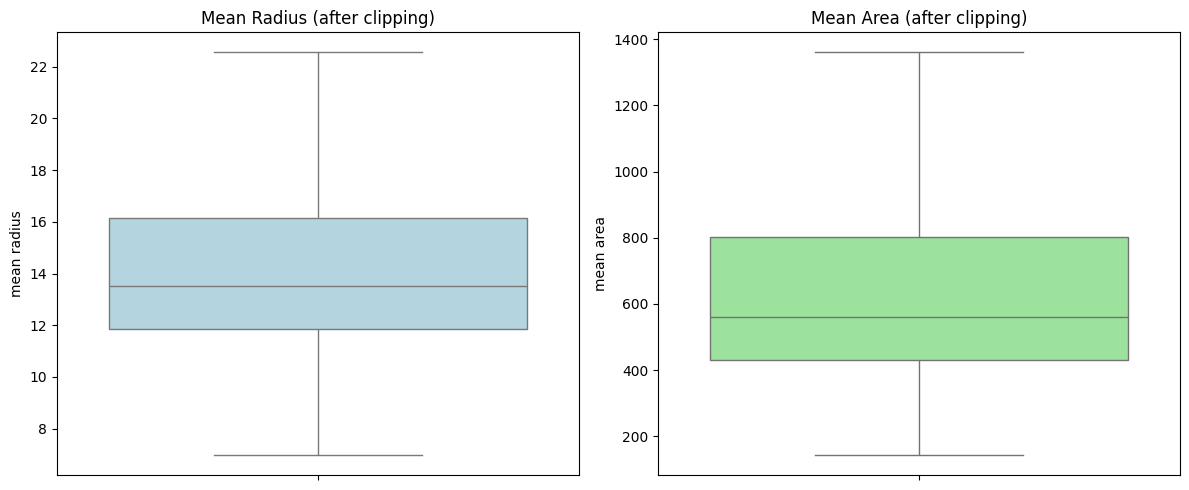

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['mean radius'], ax=axes[0], color='lightblue')
axes[0].set_title('Mean Radius (after clipping)')

sns.boxplot(y=df['mean area'], ax=axes[1], color='lightgreen')
axes[1].set_title('Mean Area (after clipping)')

plt.tight_layout()
plt.show()

In [50]:
df["tumor_location"].unique()

<StringArray>
['upper_inner', 'central', 'upper_outer', 'lower_outer', 'lower_inner']
Length: 5, dtype: str

---
## 6. Encode Categorical Features

ML models work with **numbers**, not text. We need to convert categorical columns to numeric.

### One-Hot Encoding

For categorical features without natural order, we create **one binary column per category**:

| tumor_location | → | upper_inner | central | lower_inner |
|-----------|---|-----------------|------------------|---------------|
| upper_inner|   | 1               | 0                | 0             |
| central    |   | 0               | 1                | 0             |
| lower_inner|   | 0               | 0                | 1             |

**Why not assign numbers (young=0, middle=1, old=2)?** Because the model would interpret this as an **order** (upper_inner < central < lower_inner), which may not be meaningful for all variables.

### Exercise 5.1 — One-hot encode categorical features

Use `pd.get_dummies()` to encode `age_group`, `menopause_status`, and `tumor_location`.

*Hint:* `df = pd.get_dummies(df, columns=['age_group', 'menopause_status', 'tumor_location'], drop_first=True)`

**Note:** `drop_first=True` avoids the **dummy variable trap** (redundant columns).

**Question:** How many features do we have now after encoding?

In [51]:
categorical_cols[2]

'tumor_location'

In [52]:
df['tumor_location'].unique()

<StringArray>
['upper_inner', 'central', 'upper_outer', 'lower_outer', 'lower_inner']
Length: 5, dtype: str

In [53]:
pd.get_dummies(df['tumor_location'])

,central,lower_inner,lower_outer,upper_inner,upper_outer
0,False,False,False,True,False
1,False,False,False,True,False
2,True,False,False,False,False
3,False,False,False,False,True
4,False,False,True,False,False
...,...,...,...,...,...
564,False,False,False,False,True
565,False,False,False,True,False
566,False,False,False,False,True
567,False,False,False,False,True


In [54]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"\nNew columns: {[col for col in df.columns if col not in numeric_cols and col != 'target']}")
df.head()

Shape after encoding: (569, 38)

New columns: ['age_group_old', 'age_group_young', 'menopause_status_pre', 'tumor_location_lower_inner', 'tumor_location_lower_outer', 'tumor_location_upper_inner', 'tumor_location_upper_outer']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst symmetry,worst fractal dimension,target,age_group_old,age_group_young,menopause_status_pre,tumor_location_lower_inner,tumor_location_lower_outer,tumor_location_upper_inner,tumor_location_upper_outer
0,17.99,10.38,122.80,1001.0,0.11840,0.22497,0.260855,0.140055,0.24190,0.07743,...,0.4108,0.080075,0,False,False,True,False,False,True,False
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.086900,0.070170,0.18120,0.05667,...,0.2828,0.089020,0,True,False,False,False,False,True,False
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.197400,0.127900,0.20690,0.05999,...,0.3613,0.087580,0,True,False,False,False,False,False,False
3,22.55,20.38,77.58,386.1,0.13157,0.22497,0.241400,0.105200,0.17895,0.07743,...,0.4108,0.119890,0,False,False,True,False,False,False,True
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.198000,0.104300,0.17895,0.05883,...,0.2364,0.076780,0,False,True,True,False,True,False,False


**Answer:** After one-hot encoding with `drop_first=True`, we have the original 30 numeric features + target + (2 age_group + 1 menopause + 4 tumor_location) = 38 columns total (37 features + target).

---
## 7. Feature Scaling

Same as session 1 — scale features so they have mean=0, std=1. This is important for logistic regression (gradient descent) and helps many other models too.

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

**Remember:** Fit on train, transform both train and test!

### Exercise 6.1 — Split and scale the data

Separate features (X) and target (y), split into train/test (80/20, `random_state=42`), then scale with `StandardScaler`.

*Hint:* Same pattern as session 1.

In [55]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Also scale full dataset for cross-validation later
X_scaled = scaler.fit_transform(X)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 455 samples, 37 features
Test set: 114 samples


---
## 8. Baseline: Logistic Regression

Before trying a new model, always establish a **baseline** with a model you already know. This gives you a reference point to judge whether the new model is actually better.

We'll reuse logistic regression from session 1 as our baseline.

### Exercise 7.1 — Train logistic regression baseline

Train a `LogisticRegression(max_iter=5000)` on the scaled data. Report accuracy and classification report.

**Why:** This establishes the performance we need to beat with Random Forest.

*Hint:* Same as session 1 exercises.

In [56]:
lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=target_names)}")

Logistic Regression Accuracy: 0.9737

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.97        43
      benign       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



---
## 9. Random Forest

### What is a Random Forest?

A **Random Forest** is an **ensemble** of many **decision trees**, each trained on a random subset of the data and features. The final prediction is the **majority vote** of all trees.

```
        Data
       / | \
   Tree1 Tree2 Tree3 ... TreeN
     |     |     |         |
   pred1 pred2 pred3 ... predN
          \   |   /
        Majority Vote
          → Final prediction
```

### Why Random Forest?

| Property | Logistic Regression | Random Forest |
|----------|-------------------|---------------|
| **Decision boundary** | Linear (straight line) | Non-linear (complex shapes) |
| **Feature scaling needed** | Yes | No |
| **Handles outliers** | Sensitive | Robust |
| **Interpretability** | Coefficients | Feature importances |
| **Risk of overfitting** | Low | Medium (controllable) |

### Key Idea: Ensemble Learning

Instead of relying on one model, combine many "weak" models into a strong one. Each tree sees a different random subset of the data, so they make **different errors**. When combined, the errors cancel out.

> **Medical analogy:** It's like getting opinions from multiple doctors — each may have a different perspective, but the consensus is usually more reliable than any single opinion.

### Exercise 8.1 — Train a Random Forest

Train a `RandomForestClassifier(n_estimators=100, random_state=42)` and compare its accuracy with the logistic regression baseline.

**Note:** Random Forest doesn't require scaled features, but we use the same scaled data for fair comparison.

*Hint:* Same `.fit()` / `.predict()` pattern.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest Accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=target_names)}")

### Exercise 8.2 — Compare confusion matrices

Display confusion matrices side by side for logistic regression and random forest.

**Why:** See if the models make different types of errors.

*Hint:* `fig, axes = plt.subplots(1, 2, figsize=(12, 5))`

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=target_names, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=target_names, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

### Exercise 8.3 — Feature importances

Plot the top 15 most important features according to the Random Forest.

**Why:** Random Forest can tell us which features matter most — this is valuable for understanding what drives the diagnosis.

*Hint:*
```python
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-15:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
```

**Question:** Which features are most important? Do they match the correlations from session 1?

In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), feature_names[indices])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

**Answer:** The most important features are related to `worst` and `mean` measurements of concave points, perimeter, radius, and area — consistent with the correlations found in session 1. The categorical features (age, menopause, tumor location) have low importance, which is expected since they were simulated randomly.

---
## 10. Hyperparameter Tuning

### What are Hyperparameters?

Hyperparameters are settings we choose **before** training — the model doesn't learn them from data.

| Hyperparameter | What it controls | Too low | Too high |
|---------------|-----------------|---------|----------|
| `n_estimators` | Number of trees | Unstable predictions | Slow, diminishing returns |
| `max_depth` | Maximum depth of each tree | Underfitting (too simple) | Overfitting (memorizes noise) |
| `min_samples_split` | Minimum samples to split a node | Overfitting | Underfitting |

### GridSearchCV

`GridSearchCV` tries all combinations of hyperparameters and picks the best one using cross-validation:

```
n_estimators: [50, 100, 200]  ×  max_depth: [3, 5, 10, None]  ×  min_samples_split: [2, 5]
= 3 × 4 × 2 = 24 combinations, each evaluated with 5-fold CV = 120 model fits
```

### Exercise 9.1 — Grid search for best Random Forest

Use `GridSearchCV` to find the best hyperparameters. Report the best parameters and best score.

*Hint:*
```python
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
```

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

### Exercise 9.2 — Evaluate best model on test set

Use the best model from grid search to predict on the test set. Show accuracy and classification report.

*Hint:* `grid_search.best_estimator_` gives the best model, already fitted.

**Question:** Did tuning improve performance compared to the default Random Forest?

In [ ]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

print(f"Default RF Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Tuned RF Accuracy:   {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=target_names)}")

**Answer:** Tuning may or may not improve results significantly — the default Random Forest is already quite good on this dataset. The main value of GridSearchCV is the systematic search and cross-validated evaluation, which gives us confidence in the result.

---
## 11. Cross-Validation & Final Comparison

### Exercise 10.1 — Cross-validation comparison

Run 5-fold cross-validation for both logistic regression and the best random forest. Create a comparison table.

*Hint:*
```python
lr_scores = cross_val_score(LogisticRegression(max_iter=5000), X_scaled, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(grid_search.best_estimator_, X_scaled, y, cv=5, scoring='accuracy')
```

Display results in a summary table.

In [ ]:
lr_scores = cross_val_score(LogisticRegression(max_iter=5000, random_state=42), X_scaled, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(grid_search.best_estimator_, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>12} {'Std':>12}")
print("=" * 55)
print(f"{'Logistic Regression':<25} {lr_scores.mean():>12.4f} {lr_scores.std():>12.4f}")
print(f"{'Random Forest (tuned)':<25} {rf_scores.mean():>12.4f} {rf_scores.std():>12.4f}")
print("=" * 55)

---
## 12. Summary

### What We Learned

| Step | Technique | Why |
|------|-----------|-----|
| **Missing values** | `SimpleImputer(median)` | Fill NaN values without losing samples |
| **Outliers** | IQR clipping | Reduce extreme values without removing samples |
| **Categorical encoding** | One-hot encoding (`get_dummies`) | Convert text categories to numeric features |
| **Feature scaling** | `StandardScaler` | Normalize feature ranges |
| **Baseline** | Logistic Regression | Reference performance to beat |
| **New model** | Random Forest | Ensemble of decision trees — often more powerful |
| **Tuning** | `GridSearchCV` | Find optimal hyperparameters via cross-validation |

### Data Preparation Pipeline

```
Raw Data → Handle Missing → Handle Outliers → Encode Categories → Scale → Train/Test Split → Model
```

**Key insight:** Data preparation is often more important than model choice. A well-prepared dataset with a simple model often beats a complex model on messy data.

### Next Session

- **Neural Networks (MLPClassifier)** — a third type of model
- **New dataset** — Heart Disease (different medical context)
- **Model comparison** — Logistic Regression vs Random Forest vs Neural Network